# Getting Started

Companion notebook for the RDDAC [documentation](https://rddac.readthedocs.io). It is written to stand on its own: every step is annotated so the notebook reads top to bottom.

**RDDAC** (Real Deep Drawing and Cutting) is the *experimental counterpart* to the [DDACS](https://ddacs.readthedocs.io) simulation dataset: 9 000 deep-drawn and cut cups, physically manufactured on a press and measured — press force signals, sheet-thickness and oil-film traverses on the incoming blank, and high-resolution laser scans of the part after drawing (OP10) and after cutting (OP20). The 9 000 experiments cover 18 categories (2 geometries x 3 blankholder forces x 3 oil types, 500 repetitions each): ids 0–4499 are concave, 4500–8999 convex.

The `rddac` package mirrors the `ddacs` API 1:1, so DDACS code ports by swapping the import.

## Walkthrough

1. install the package and verify the import,
2. download the small sample bundle from DaRUS,
3. load the Croissant manifest and list the published RecordSets,
4. iterate one record from the experiment index,
5. open a single HDF5 experiment file and print its structure,
6. render the OP10 laser scan as a height image.

## Assumptions

- This notebook lives in `notebooks/` of the repository and reads the dataset from `../data/` (the local staging copy of the published files; on your machine this is whatever directory `rddac download` wrote to — typically `./data`).
- The data directory contains `metadata.json`, `process_parameters.csv`, and at least the bundled `sample.zip`.

## 1. Install and verify

Run once per environment from a terminal:

```bash
pip install rddac           # core
pip install rddac[torch]    # optional, for the PyTorch adapter
```

For hardware-specific PyTorch builds (CUDA, ROCm, MPS) install PyTorch first from [pytorch.org](https://pytorch.org/get-started/locally/) and then `pip install rddac` without the extra; the package does not pin PyTorch so an existing wheel is preserved.

Verifying that the import works also confirms the version this notebook was written against.

In [1]:
import warnings
warnings.filterwarnings('ignore')   # silence mlcroissant's verbose validation warnings

import rddac
print('rddac', rddac.__version__)

rddac 0.1.0


## 2. Download the sample bundle

From the **repository root** (not from inside `notebooks/`):

```bash
rddac download --small
```

The command writes `metadata.json`, `process_parameters.csv`, and the bundled sample zip (`sample.zip`, 18 experiments — one per category) into `./data/`. The full release is fetched with `rddac download` instead (`concave.zip` + `convex.zip`, ~87 GB). The zips are **not** extracted; the HDF5 members are read in place via the `zipfile` module so there is no second copy on disk.

Because RDDAC is the experimental counterpart to DDACS, the full download **also fetches the matching FEM simulations automatically**: the CLI queries the DDACS dataset on DaRUS and downloads its `rddac.zip` (the RDDAC sub-study subset, 398 simulations) into `./data/simulation/` — no manual DDACS download required. Skip them with `--no-sim`; the `--small` and `--files` forms never include them.

Defining `DATA_DIR` and the example `experiment_id` here once keeps the rest of the notebook readable.

In [2]:
from pathlib import Path

DATA_DIR = Path('../data')   # this notebook lives under notebooks/, data sits at the repo root
# DATA_DIR = Path('./data')         # uncomment instead when running from the repository root
experiment_id = 0                   # one of the 18 experiments bundled in sample.zip

assert (DATA_DIR / 'metadata.json').is_file(), f'{DATA_DIR} does not contain the dataset'

## 3. Inspect one experiment

`rddac.open_h5(experiment_id, data_dir=...)` is the single-experiment escape hatch. It:

1. looks at the manifest's distribution to find the zip that contains the zero-padded `<experiment_id>.h5` (`0` -> `0000.h5`),
2. reads the HDF5 member into an in-memory `BytesIO`,
3. returns an `h5py.File` opened on the buffer in read-only mode.

Each experiment file carries four groups, all in **raw, uncalibrated sensor units**:

- `force/data` — `(n, 8)` press signal table; the column names and units are stored as attributes on the group. `n` varies per experiment.
- `sheet_thickness/data` — `(n, 2)` traverse `[sensor_position, value]`, measured along a single line on the **bare blank before the oil is applied** (incoming material check).
- `oil_thickness/data` — `(n, 2)` traverse, measured **after lubrication** (missing when `has_oil` is false).
- `pointcloud/op10` and `pointcloud/op20` — flat `(6 400 000,)` height (`z`) and `luminescence` buffers over a 2000 x 3200 scan grid. OP10 is the part after deep drawing, OP20 after cutting (missing when `has_pointcloud` is false).

`rddac.inspect_h5` prints the full hierarchy in a tree (lines starting with `@` are HDF5 attributes, trailing `/` marks a group, bare names show shape and dtype).

In [3]:
with rddac.open_h5(experiment_id, data_dir=DATA_DIR) as f:
    print(list(f.keys()))

['force', 'oil_thickness', 'pointcloud', 'sheet_thickness']


In [4]:
with rddac.open_h5(experiment_id, data_dir=DATA_DIR) as f:
    rddac.inspect_h5(f)

├── @blankholder_force = 100
├── @blankholder_force_unit = kN
├── @category = 0
├── @experiment_id = 1
├── @geometry = concave
├── @has_oil = True
├── @has_pointcloud = True
├── @id = 0
├── @mean_punch_temp = 20.2
├── @mean_punch_temp_unit = degC
├── @n_force_measurements = 1140
├── @n_oil_measurements = 421
├── @n_pointcloud_measurements = 6400000
├── @n_sheet_measurements = 208
├── @oil_type = coarse
├── force/
│   ├── @columns = ['time' 'load_cell_1' 'load_cell_2' 'load_cell_3' 'load_cell_4'
 'punch_temp' 'punch_pos' 'total_force']
│   ├── @n_measurements = 1140
│   ├── @units = ['s' 'kN' 'kN' 'kN' 'kN' 'degC' 'mm' 'kN']
│   └── data  (1140, 8) float32
├── oil_thickness/
│   ├── @columns = ['sensor_position' 'oil_value']
│   ├── @n_measurements = 421
│   ├── @units = ['mm' 'g/m^2']
│   └── data  (421, 2) float32
├── pointcloud/
│   ├── op10/
│   │   ├── @x_shape = 3200
│   │   ├── @y_shape = 2000
│   │   ├── luminescence  (6400000,) float32
│   │   └── z  (6400000,) float32
│   └── 

## 4. First plot

The next cell renders the OP10 laser scan — the formed cup after deep drawing — as a 3D point cloud. Two buffers drive the plot:

- **`z`** : the raw height buffer, a flat `(6400000,)` array stored row-major over the 2000 x 3200 pixel grid (see the `x_shape` / `y_shape` attributes on the group).
- **`luminescence`** : the matching intensity buffer. Pixels where the scanner measured nothing carry `0`; passing the buffer to `scan_to_pointcloud` drops them, so only real measurements become points.

`rddac.scan_to_pointcloud` turns the buffers into an `(N, 3)` array of `[x_px, y_px, z_raw]`; `stride=4` keeps every fourth pixel in both axes (~400k points instead of 6.4 million — plenty for a preview). The height values are raw sensor units (uncalibrated) — good enough for inspection; the mm calibration belongs to the planned preprocessing step.

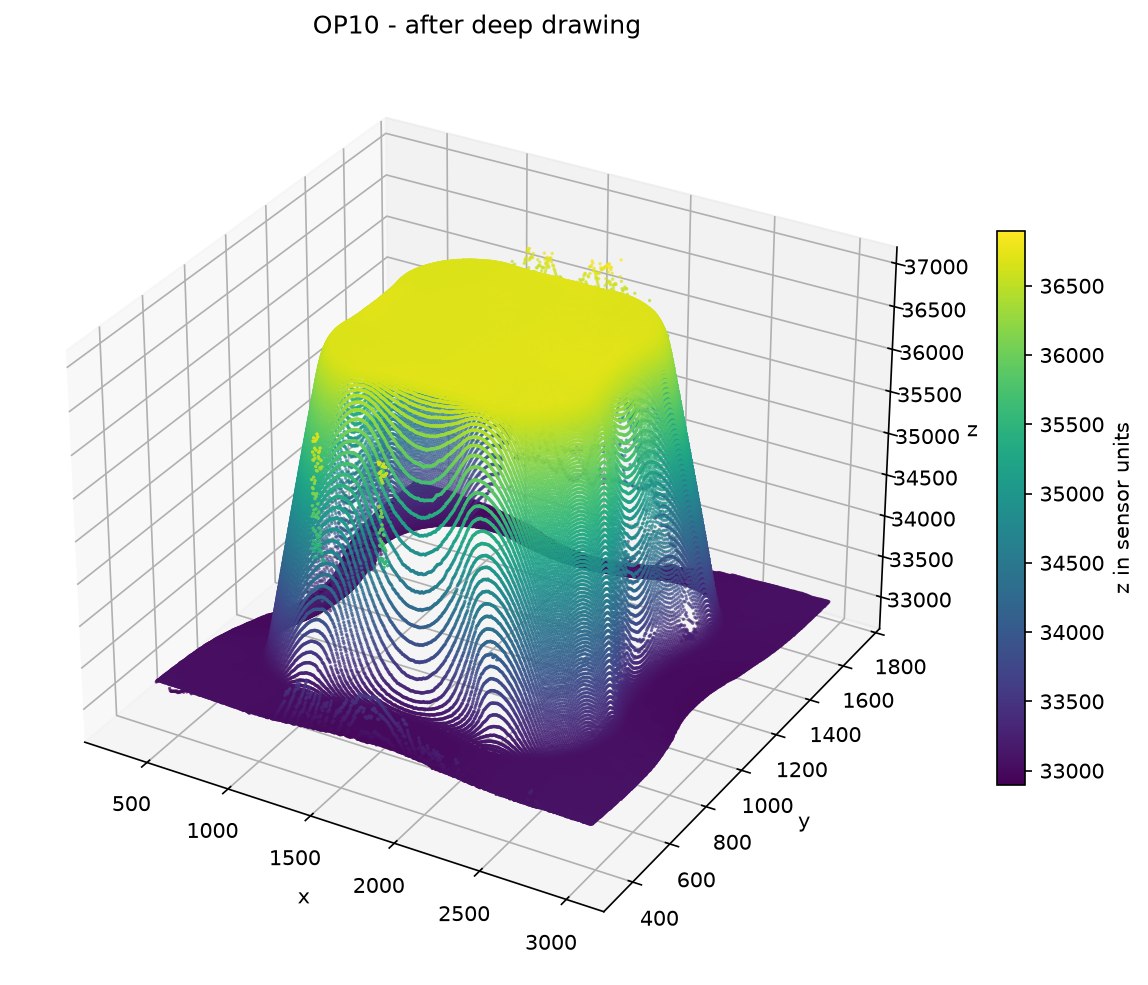

In [5]:
import matplotlib.pyplot as plt

with rddac.open_h5(experiment_id, data_dir=DATA_DIR) as f:
    z    = f['pointcloud/op10/z'][:]
    lumi = f['pointcloud/op10/luminescence'][:]

points = rddac.scan_to_pointcloud(z, lumi, stride=4)      # (N, 3): x_px, y_px, z_raw
ax, cbar = rddac.plot_point_cloud(points, point_size=0.4, title='OP10 - after deep drawing')
cbar.set_label('z in sensor units')
plt.show()